<div align="center">

#####

#Teoría de Circuitos 2

##Trabajo Práctico - Laboratorio 2

**Estudiante: Nahir Lewartowski**

</div>

---

#**Objetivo**

Implementando filtros RC y un NUCLEO-F446RE, diseñaremos, experimentaremos y analizaremos el comportamiento de los filtros digitales.

#**Diseño de filtros RC**

Establecemos una frecuencia de corte a los 1000Hz y un capacitor cerámico estándar de 10nF (o en su código, el 103). Con esto podemos establecer el resistor necesario para los filtros RC.

$$f_c = \frac{1}{2\pi R C} = 1000\text{ Hz}$$

$$R = 15.9kΩ$$

Adaptado a valores estandarizados, usaremos resistores de 15k$Ω$.

#**Armado y preparación**

Una vez definidos los componentes necesarios para los filtros RC, procedemos a conectar el primero de ellos al generador de señales, mientras que el otro irá con su salida conectada al osciloscopio. Entre la salida del primero y la entrada del segundo conectaremos el NUCLEO-F446RE.

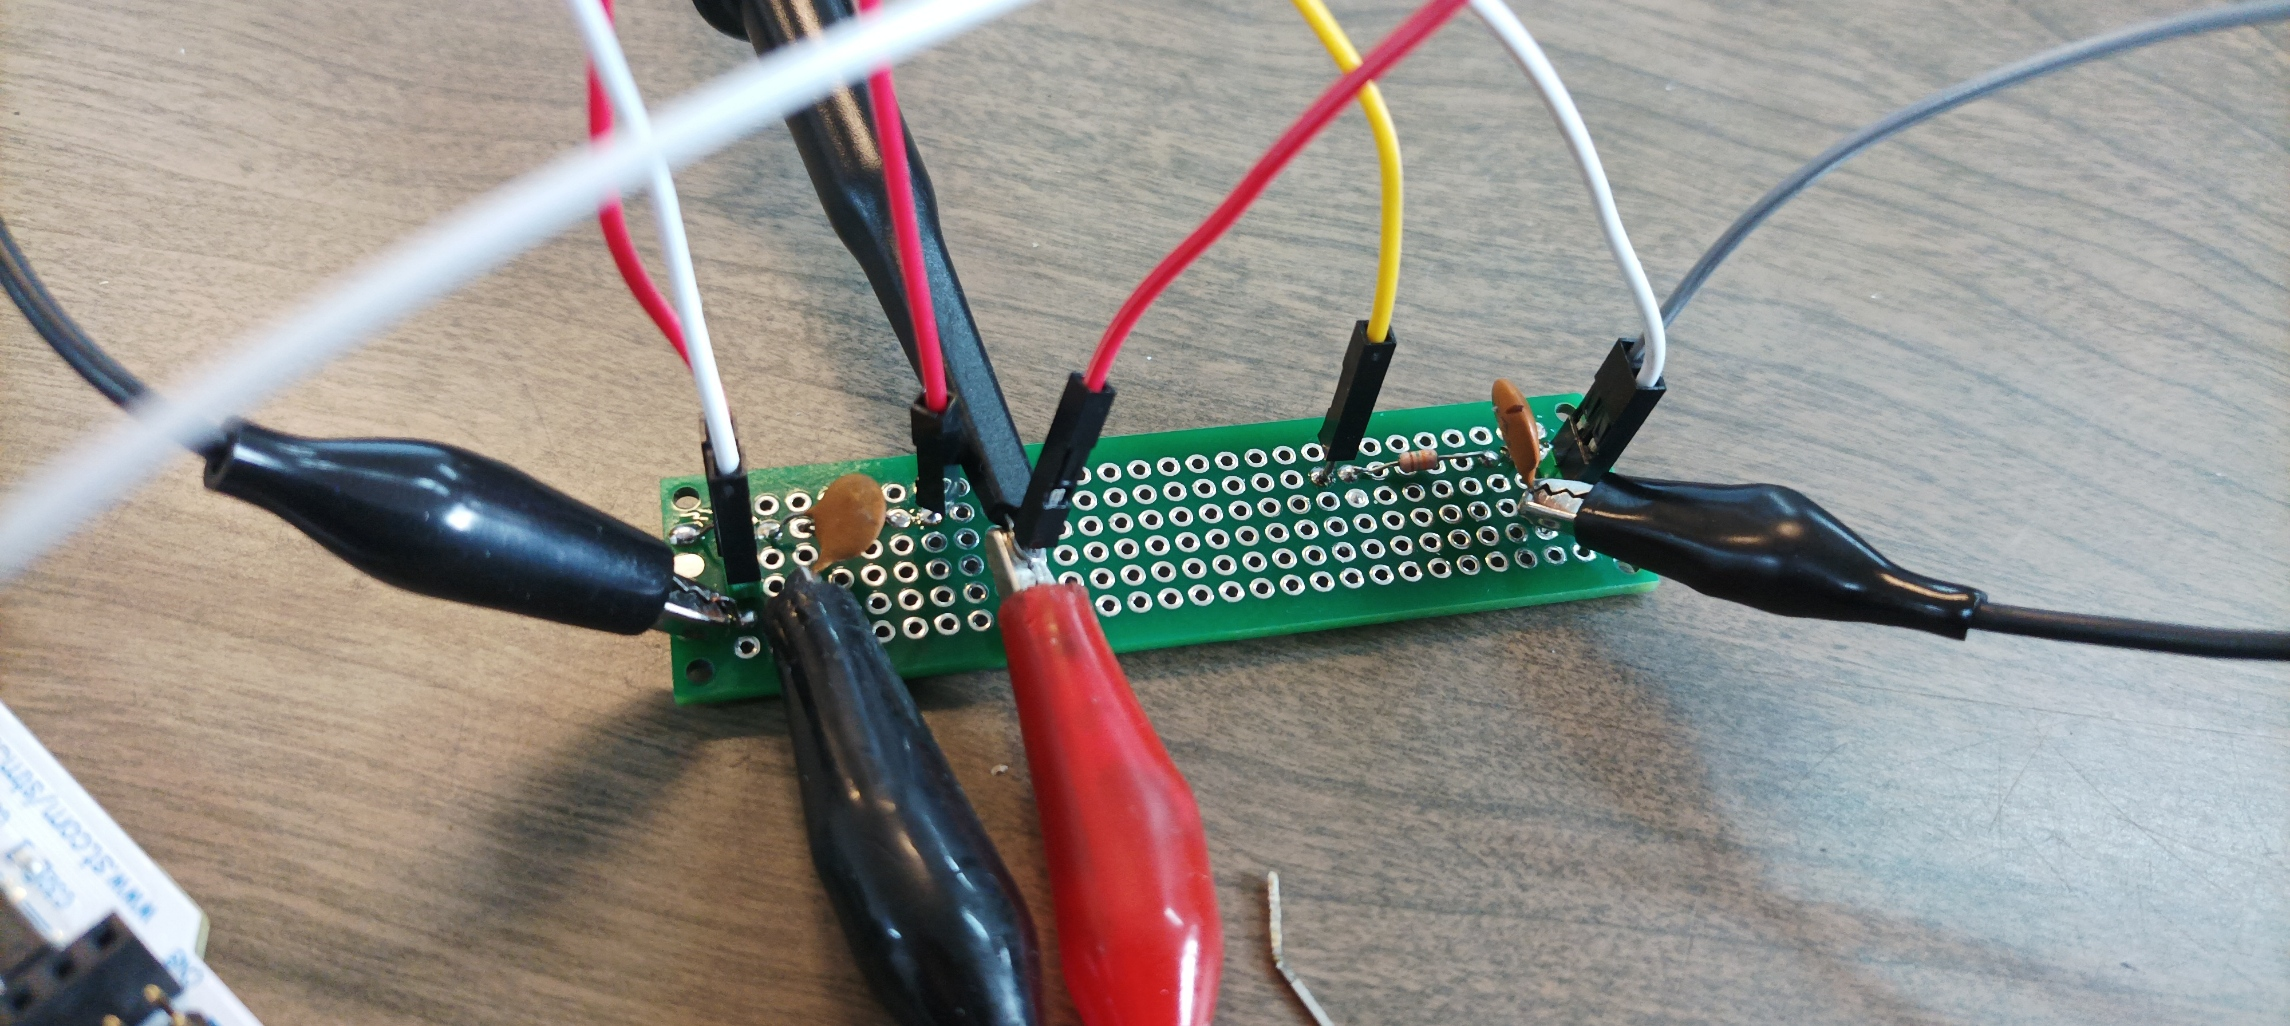

Figura 1: Montaje físico de los filtros RC sobre placa perforada, detallando las conexiones mediante cables con pinzas cocodrilo.

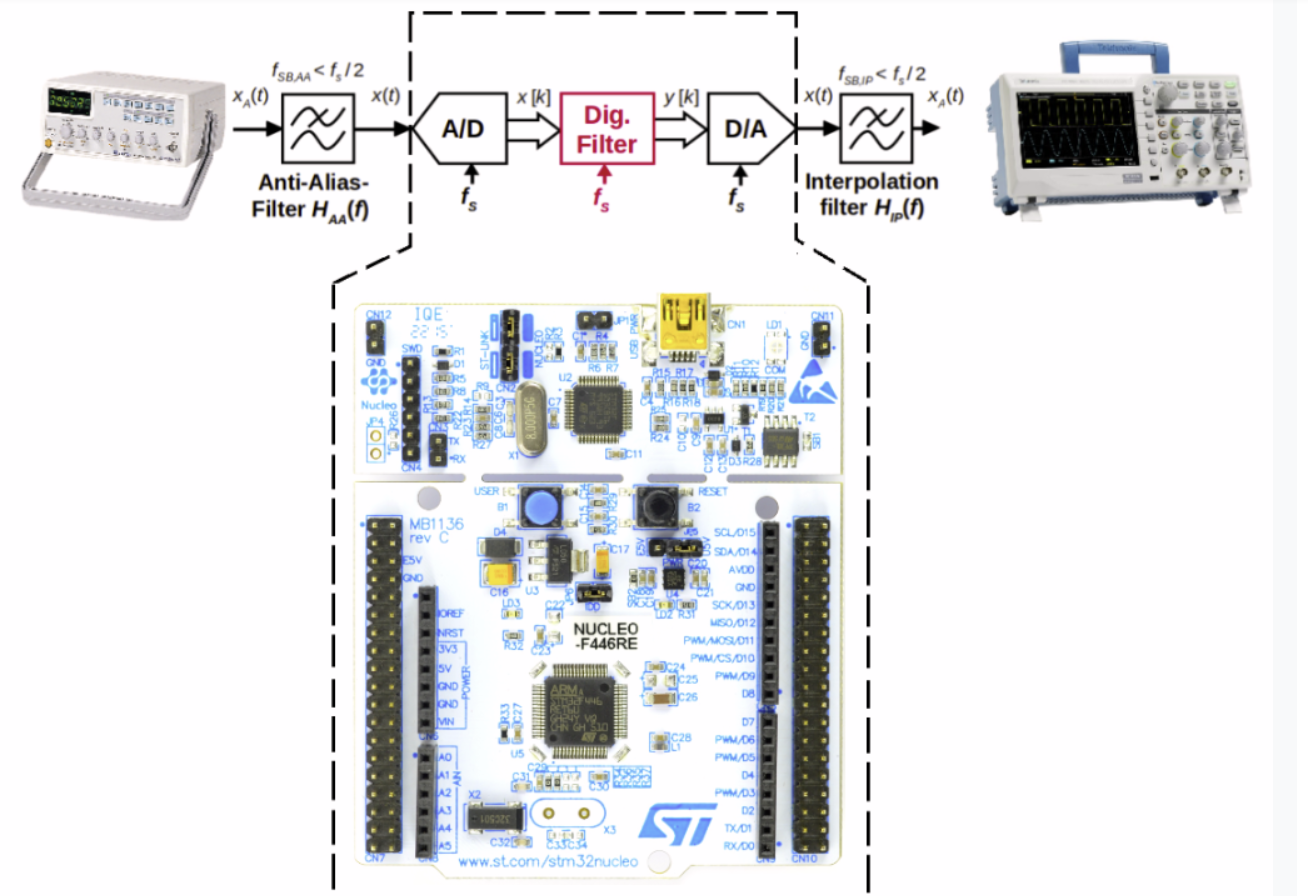

Figura 2: Diagrama en bloques del sistema de procesamiento digital, ilustrando la cadena de señal desde el filtro anti-aliasing hasta el filtro de reconstrucción a través de la NUCLEO-F446RE.

Establecemos en el generador de señales un offset de 1.65V y una amplitud senoidal de 1V.

Filtro RC de entrada (Anti-Aliasing, $H_{AA}$): Limita el ancho de banda analógico por debajo de Nyquist ($f < f_s/2$) para evitar que ruidos o frecuencias altas se plieguen como componentes espurias dentro del ADC.

Filtro RC de salida (Reconstrucción, $H_{IP}$): Suaviza los escalones del conversor D/A (retenedor de orden cero) e interpola las muestras en el tiempo, eliminando las réplicas armónicas de conmutación para entregar una señal continua al osciloscopio.

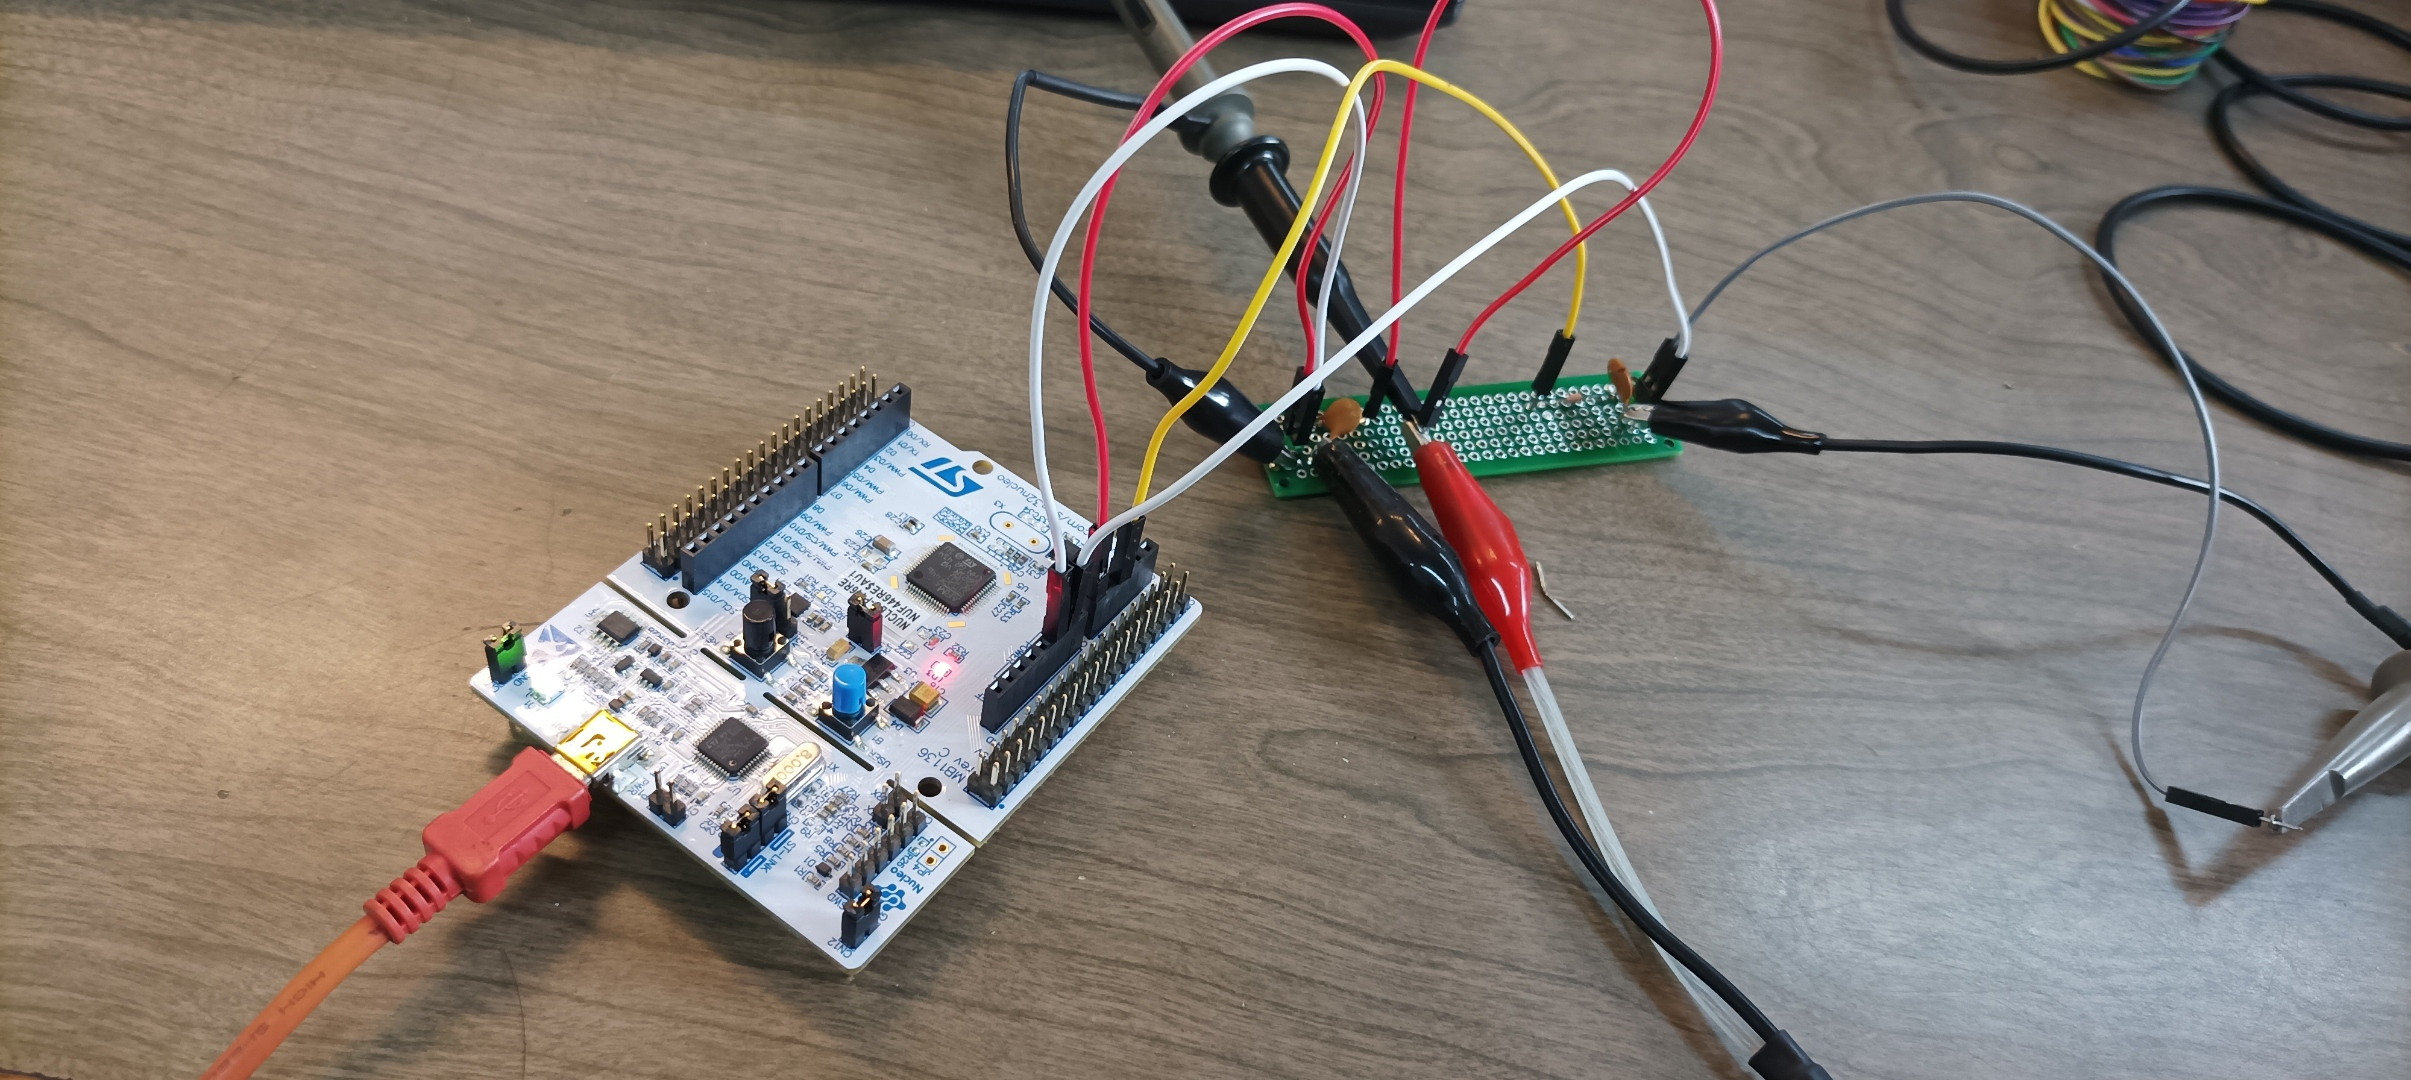

Figura 3: Disposición general del hardware, vinculando la etapa de filtrado analógico con la placa de desarrollo y las sondas de medición.

Sabiendo que un filtro RC tiene ganancia -3dB, al implementar dos de ellos deberíamos ver -6dB a la salida.

#**Diseño de filtros digitales**

Pretendemos generar dos filtros: IIR y FIR. Para ello, usaremos Python para hallar los coeficientes necesarios para cada cada uno.

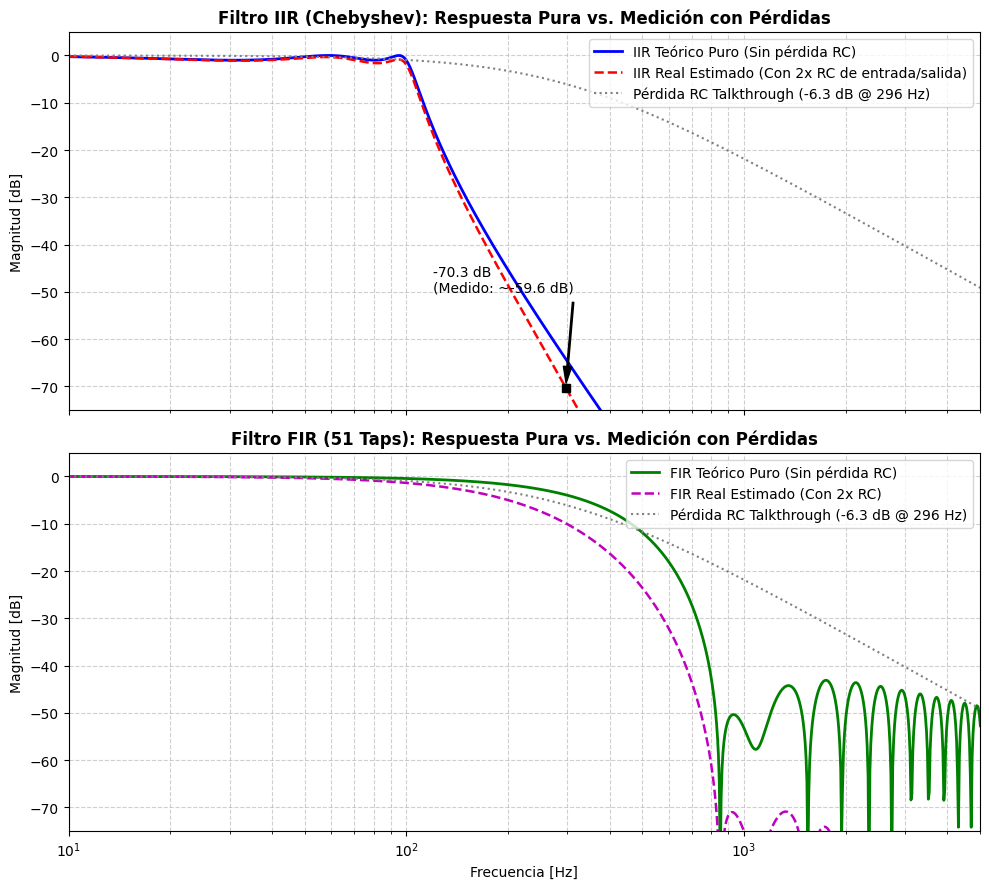

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

fs = 20000.0
worN = np.logspace(1, 3.7, 1000)

# ==========================================
# COEFICIENTES DEL FIR
fir_taps = np.array([
    0.002704536,
    0.002851002,
    0.003245983,
    0.003889145,
    0.004775657,
    0.005896216,
    0.007237165,
    0.008780684,
    0.010505074,
    0.012385110,
    0.014392458,
    0.016496169,
    0.018663213,
    0.020859059,
    0.023048291,
    0.025195245,
    0.027264646,
    0.029222255,
    0.031035485,
    0.032674005,
    0.034110288,
    0.035320123,
    0.036283062,
    0.036982792,
    0.037407441,
    0.037549797,
    0.037407441,
    0.036982792,
    0.036283062,
    0.035320123,
    0.034110288,
    0.032674005,
    0.031035485,
    0.029222255,
    0.027264646,
    0.025195245,
    0.023048291,
    0.020859059,
    0.018663213,
    0.016496169,
    0.014392458,
    0.012385110,
    0.010505074,
    0.008780684,
    0.007237165,
    0.005896216,
    0.004775657,
    0.003889145,
    0.003245983,
    0.002851002,
    0.002704536,
])

# ==========================================
# COEFICIENTES DEL IIR
sos_iir = np.array([
    [1.15756630e-10, 2.31513260e-10, 1.15756630e-10, 1.0, -0.990945727, 0.0],
    [1.0, 2.0, 1.0, 1.0, -1.98497166, 0.98539229],
    [1.0, 1.0, 0.0, 1.0, -1.99342320, 0.994395821],
])

# ==========================================
# CÁLCULO DE RESPUESTAS EN FRECUENCIA

# Filtro FIR Digital Puro
w_fir, h_fir = signal.freqz(fir_taps, worN=worN, fs=fs)
mag_fir_ideal = 20 * np.log10(np.abs(h_fir) + 1e-12)

# Filtro IIR Digital Puro
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=worN, fs=fs)
mag_iir_ideal = 20 * np.log10(np.abs(h_iir) + 1e-12)

# Canal Analógico RC (Entrada + Salida en cascada)
fc_rc = 296.6
h_rc_single = 1.0 / np.sqrt(1.0 + (worN / fc_rc) ** 2)
# Dos filtros RC en cascada (Antialias + Reconstrucción)
h_rc_total = h_rc_single * h_rc_single
mag_rc_dB = 20 * np.log10(h_rc_total)

# Respuestas Combinadas (Digital + RC Analógicos)
mag_fir_con_rc = mag_fir_ideal + mag_rc_dB
mag_iir_con_rc = mag_iir_ideal + mag_rc_dB

# ==========================================
# GRAFICACIÓN
fig, axs = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# ---- GRÁFICA 1: FILTRO IIR ----
axs[0].semilogx(
    worN,
    mag_iir_ideal,
    "b-",
    linewidth=2,
    label="IIR Teórico Puro (Sin pérdida RC)",
)
axs[0].semilogx(
    worN,
    mag_iir_con_rc,
    "r--",
    linewidth=1.8,
    label="IIR Real Estimado (Con 2x RC de entrada/salida)",
)
axs[0].semilogx(
    worN,
    mag_rc_dB,
    "gray",
    linestyle=":",
    label="Pérdida RC Talkthrough (-6.3 dB @ 296 Hz)",
)

idx_marker = np.argmin(np.abs(worN - 296.6))
axs[0].plot(296.6, mag_iir_con_rc[idx_marker], "ks")
axs[0].annotate(
    f"{mag_iir_con_rc[idx_marker]:.1f} dB\n(Medido: ~-59.6 dB)",
    xy=(296.6, mag_iir_con_rc[idx_marker]),
    xytext=(120, -50),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
)

axs[0].set_title(
    "Filtro IIR (Chebyshev): Respuesta Pura vs. Medición con Pérdidas",
    fontsize=12,
    fontweight="bold",
)
axs[0].set_ylabel("Magnitud [dB]")
axs[0].set_ylim([-75, 5])
axs[0].grid(True, which="both", linestyle="--", alpha=0.6)
axs[0].legend(loc="upper right")

# ---- GRÁFICA 2: FILTRO FIR ----
axs[1].semilogx(
    worN,
    mag_fir_ideal,
    "g-",
    linewidth=2,
    label="FIR Teórico Puro (Sin pérdida RC)",
)
axs[1].semilogx(
    worN,
    mag_fir_con_rc,
    "m--",
    linewidth=1.8,
    label="FIR Real Estimado (Con 2x RC)",
)
axs[1].semilogx(
    worN,
    mag_rc_dB,
    "gray",
    linestyle=":",
    label="Pérdida RC Talkthrough (-6.3 dB @ 296 Hz)",
)

axs[1].set_title(
    "Filtro FIR (51 Taps): Respuesta Pura vs. Medición con Pérdidas",
    fontsize=12,
    fontweight="bold",
)
axs[1].set_xlabel("Frecuencia [Hz]")
axs[1].set_ylabel("Magnitud [dB]")
axs[1].set_xlim([10, 5000])
axs[1].set_ylim([-75, 5])
axs[1].grid(True, which="both", linestyle="--", alpha=0.6)
axs[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

Figura 4: Simulación en Python de la respuesta en frecuencia de los filtros IIR y FIR, contrastando los modelos digitales puros con la estimación real considerando las pérdidas RC.

Línea punteada gris: Indica la atenuación de los dos filtros RC analógicos en cascada, que actúan como anti-aliasing y reconstrucción. Se observa que a 296.6 Hz (punto de referencia), la atenuación es de aproximadamente -6.3 dB, lo que corresponde a la caída que esperábamos por el doble filtro RC.

#**Código y coeficientes implementados**

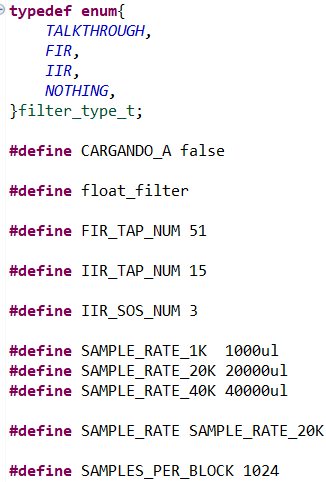

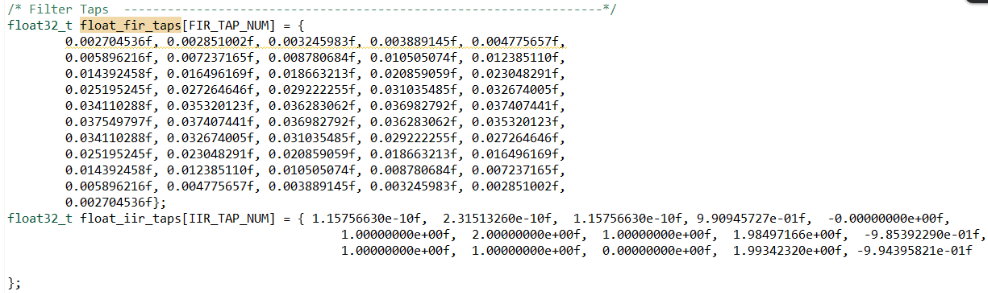

#**Talkthrough**

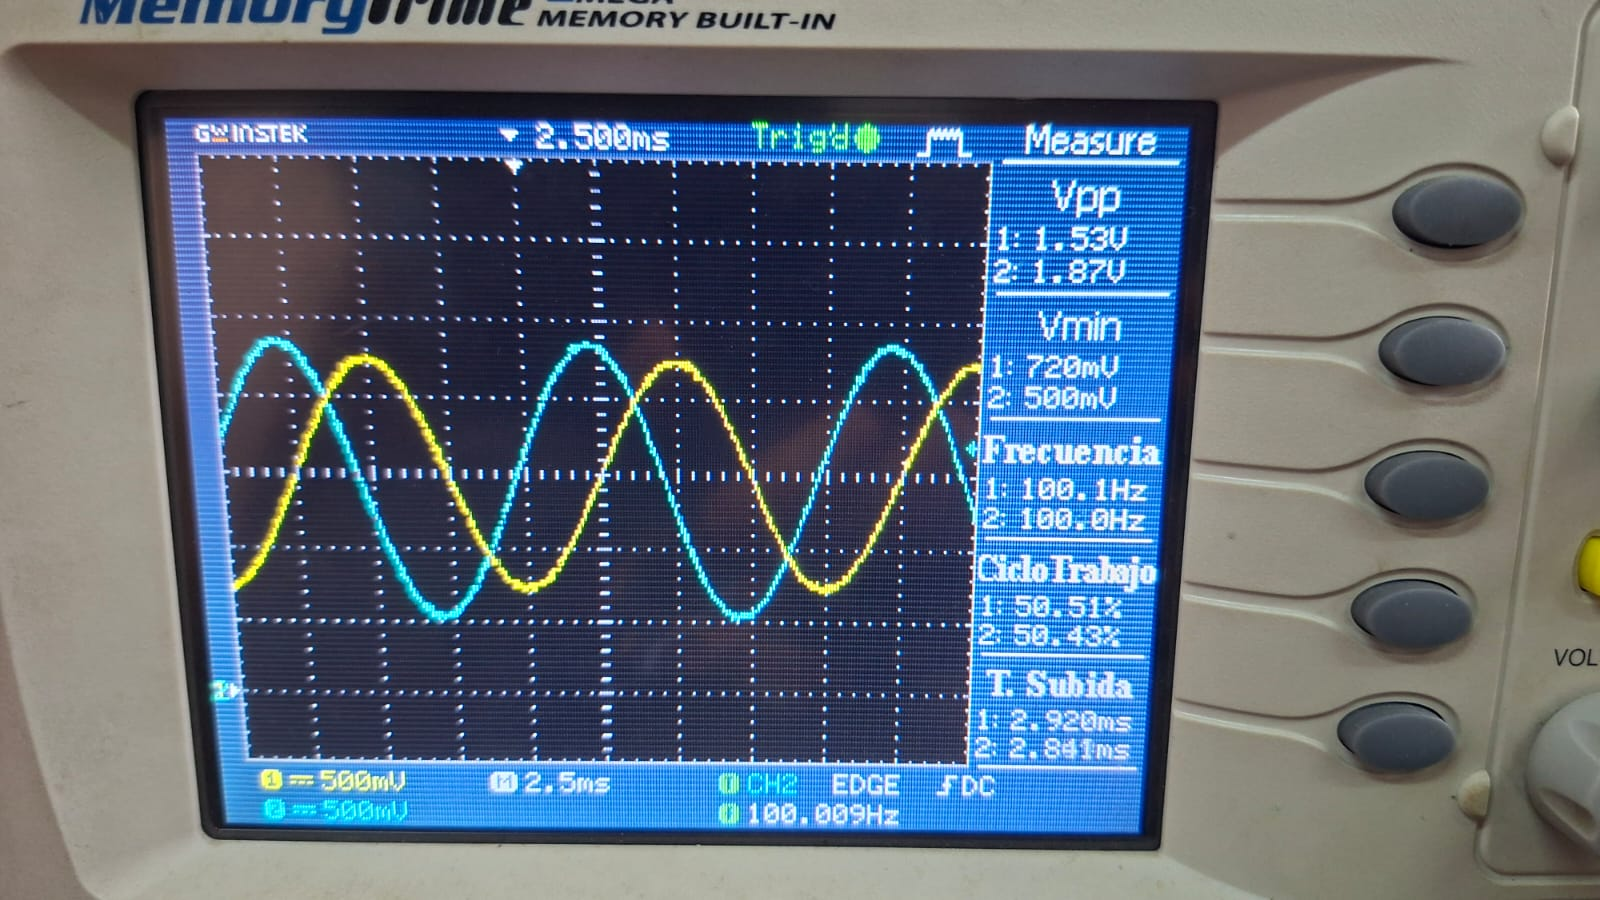

Figura 5: Captura del osciloscopio durante la prueba de Talkthrough, evidenciando el comportamiento de las señales senoidales de entrada y salida a 100 Hz.

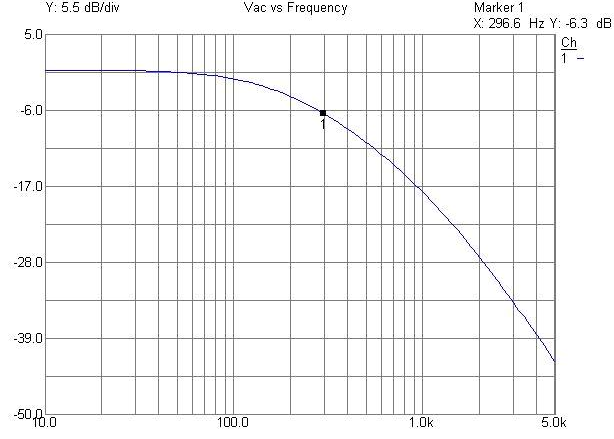

Figura 6: Respuesta en frecuencia medida para la configuración Talkthrough, registrando la atenuación esperada de -6.3 dB a 296.6 Hz.

El Talkthrough permite observar el comportamiento de los filtros RC analógicos sin ningún procesamiento digital de por medio. Se puede apreciar la caída de -3dB en la frecuencia de corte y la atenuación de -6dB por octava.

#**IIR**

In [ ]:
import numpy as np
from scipy import signal

# ==============================================================================
# PARÁMETROS
fs = 20000.0
wp = 100.0
ws = 300.0

# Tolerancias en dB
gpass = 1.0
gstop = 60.0

# ==============================================================================
# DISEÑO DEL FILTRO
sos = signal.iirdesign(
    wp=wp,
    ws=ws,
    gpass=gpass,
    gstop=gstop,
    analog=False,
    ftype='cheby1',
    output='sos',
    fs=fs
)

num_secciones = sos.shape[0]
print(sos)

[[ 1.15756630e-10  2.31513260e-10  1.15756630e-10  1.00000000e+00
  -9.90945727e-01  0.00000000e+00]
 [ 1.00000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00
  -1.98497166e+00  9.85392290e-01]
 [ 1.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
  -1.99342320e+00  9.94395821e-01]]


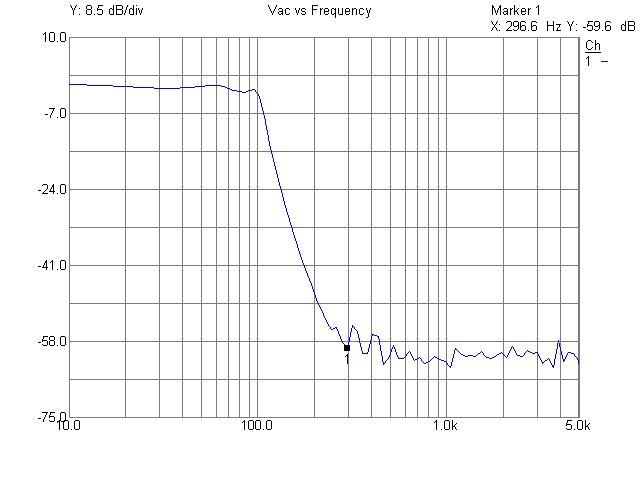

Figura 7: Medición instrumental de la respuesta en frecuencia del filtro digital IIR, mostrando una atenuación de -59.6 dB en la frecuencia de referencia de 296.6 Hz.

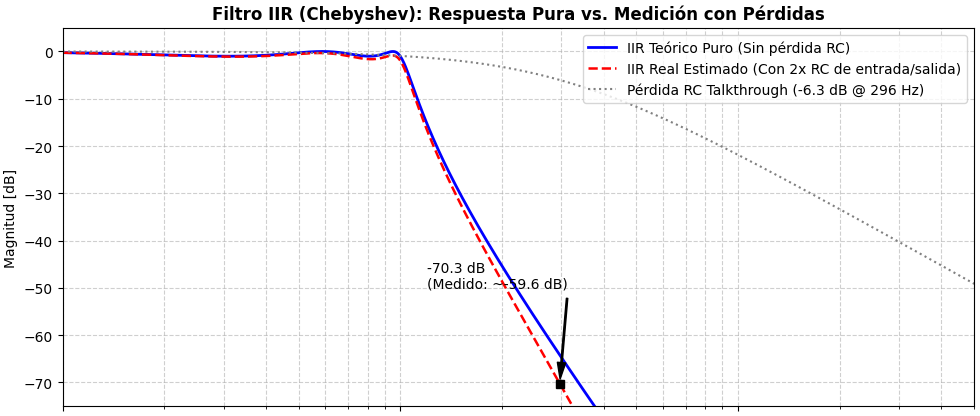

Figura 8: Curva teórica del filtro IIR (Chebyshev) generada por simulación, utilizada como parámetro de comparación frente a las mediciones físicas.

Las diferencias entre la expectativa y la realidad pueden deberse a imperfecciones de los componentes, ruido o limitaciones del sistema de medición.

#**FIR**

In [ ]:
import numpy as np
from scipy import signal

# ==============================================================================
# PARÁMETROS
fs = 20000.0
numtaps = 51
fc = 100.0

h = signal.firwin(numtaps, cutoff=fc, fs=fs, window='hamming')

print("=" * 60)
print("/* Para filter.h */")
print(f"#define FIR_TAP_NUM     {numtaps}")
print("=" * 60)
print("/* Para app.c */")
print("filter_type_t filter = FIR;")
print(f"float32_t float_fir_taps[{numtaps}] = {{")
for i in range(0, numtaps, 5):
    chunk = h[i:i+5]
    line = ", ".join([f"{val:.9f}f" for val in chunk])
    comma = "," if i + 5 < numtaps else ""
    print(f"    {line}{comma}")
print("};")
print("=" * 60)

/* Para filter.h */
#define FIR_TAP_NUM     51
/* Para app.c */
filter_type_t filter = FIR;
float32_t float_fir_taps[51] = {
    0.002704536f, 0.002851002f, 0.003245983f, 0.003889145f, 0.004775657f,
    0.005896216f, 0.007237165f, 0.008780684f, 0.010505074f, 0.012385110f,
    0.014392458f, 0.016496169f, 0.018663213f, 0.020859059f, 0.023048291f,
    0.025195245f, 0.027264646f, 0.029222255f, 0.031035485f, 0.032674005f,
    0.034110288f, 0.035320123f, 0.036283062f, 0.036982792f, 0.037407441f,
    0.037549797f, 0.037407441f, 0.036982792f, 0.036283062f, 0.035320123f,
    0.034110288f, 0.032674005f, 0.031035485f, 0.029222255f, 0.027264646f,
    0.025195245f, 0.023048291f, 0.020859059f, 0.018663213f, 0.016496169f,
    0.014392458f, 0.012385110f, 0.010505074f, 0.008780684f, 0.007237165f,
    0.005896216f, 0.004775657f, 0.003889145f, 0.003245983f, 0.002851002f,
    0.002704536f
};


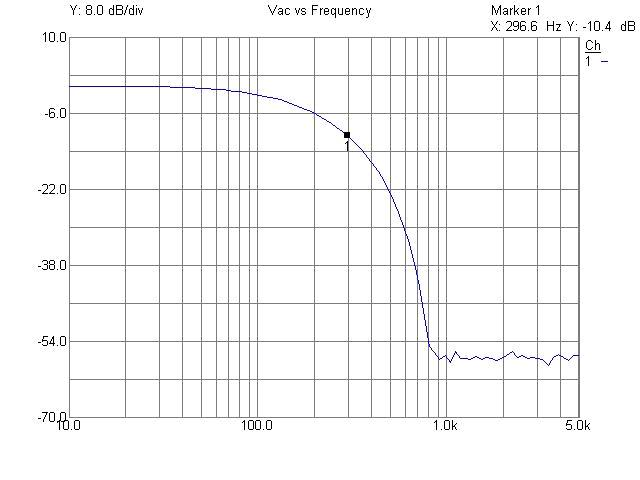

Figura 9: Medición instrumental de la respuesta en frecuencia del filtro digital FIR (51 taps), señalando una atenuación de -10.4 dB a 296.6 Hz.

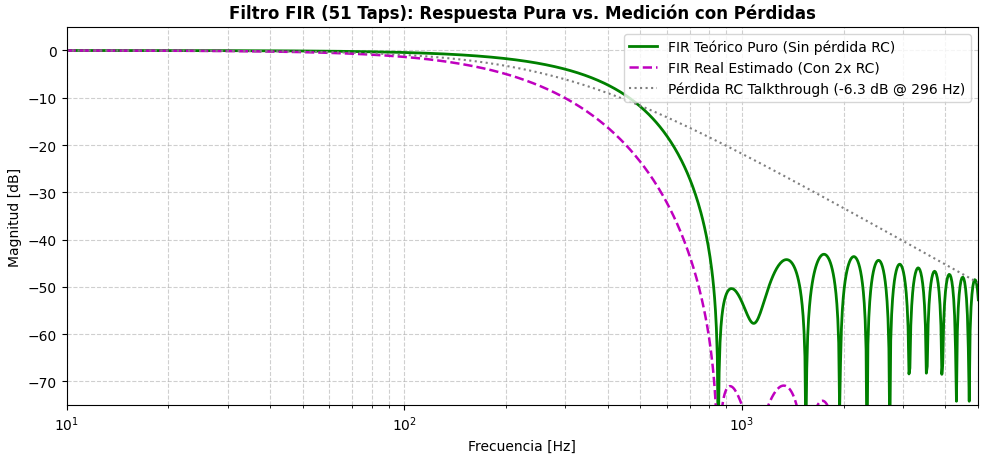

Figura 10: Curva teórica del filtro FIR generada por simulación, empleada como expectativa ideal para contrastar la fidelidad del circuito implementado.

## Conclusión

Ambos gráficos obtenidos en la práctica se asemejan a sus correspondientes simulaciones, particularmente el FIR resultó muy fiel, esto puede deberse a múltiples factores: Al haber usado una placa perforada para soldar los filtros RC y no simplemente usar una protoboard, hemos evitado ruidos extra por mal contacto. También la menor cantidad de muestras pudo haber afectado a la resolución de las gráficas, a comparación de otros filtros implementados por nuestros pares cuyas experimentaciones eran levemente más erráticas.


